# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
   
The penalty keeps coefficients small so the model doesn’t get too complicated and overfit.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization lets us control complexity: big α = simpler model (high bias, low variance), small α = more complex model (low bias, high variance).

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge shrinks all coefficients but keeps them, while LASSO can shrink some to exactly 0, removing variables. Ridge keeps everything; LASSO does feature selection.

4. How do we typically scale variables for use in regularized regression? Why?

We scale variables to have mean 0 and standard deviation 1 so all features are treated equally by the penalty.

5. How is the penalty $\alpha$ typically selected?

α is chosen using cross validation by picking the value that gives the lowest error.


6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

We do not include the penalty in cross validated MSE because we only care about how well the model predicts new data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

## 1)

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("data/cars_hw.csv")


df = df.drop(columns=["Unnamed: 0"])


df["Age"] = 2024 - df["Make_Year"]

X = df[["Mileage_Run", "Age"]]
y = df["Price"]

poly = PolynomialFeatures(3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

features = poly.get_feature_names_out(["Mileage_Run", "Age"])

## 2)

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)

print(pd.Series(lr.coef_, index=features))

Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


## 3)

In [20]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.323e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.319e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([ 10. ...000. ])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 4)

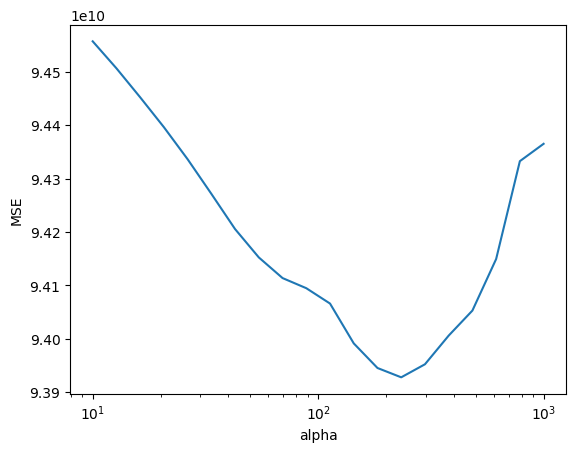

In [21]:
import matplotlib.pyplot as plt

plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.show()

## 5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

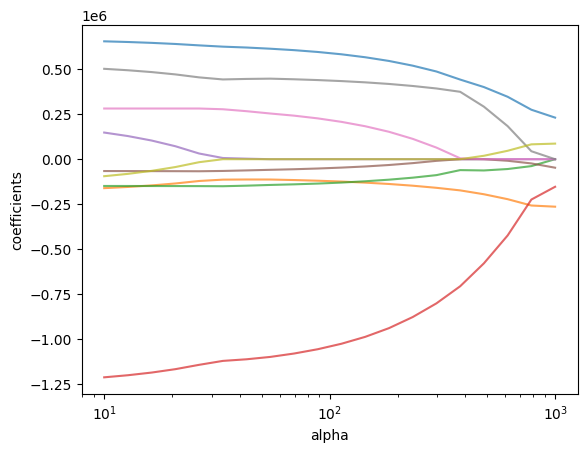

In [22]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import numpy as np

coef_path = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_scaled, y)
    coef_path.append(model.coef_)

coef_path = np.array(coef_path)

for i in range(coef_path.shape[1]):
    plt.plot(alphas, coef_path[:, i], alpha=0.7)

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

## 6)

In [23]:
coefs = pd.Series(lasso.coef_, index=features)

print("Selected features:")
print(coefs[coefs != 0])

print("Proportion zero:", (coefs == 0).mean())

Selected features:
Mileage_Run          541816.554848
Age                 -211301.604371
Mileage_Run^2       -313330.303312
Mileage_Run Age     -637593.936568
Age^2                  5841.326277
Mileage_Run^3          2735.702468
Mileage_Run^2 Age    297787.051885
Mileage_Run Age^2    100600.242401
Age^3                 95884.589970
dtype: float64
Proportion zero: 0.0


## 7)

In [27]:
print(pd.DataFrame({
    "Linear": lr.coef_,
    "LASSO": lasso.coef_
}, index=features))

                         Linear          LASSO
Mileage_Run        6.686165e+05  541816.554848
Age               -1.841941e+05 -211301.604371
Mileage_Run^2     -1.494679e+05 -313330.303312
Mileage_Run Age   -1.251592e+06 -637593.936568
Age^2              2.156399e+05    5841.326277
Mileage_Run^3     -6.514490e+04    2735.702468
Mileage_Run^2 Age  2.833392e+05  297787.051885
Mileage_Run Age^2  5.280829e+05  100600.242401
Age^3             -1.389370e+05   95884.589970


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

## 1)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

num_vars = ["age", "ejection_fraction", "serum_creatinine"]
cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

X_num = df[num_vars]
X_cat = df[cat_vars]
y = df["DEATH_EVENT"]

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly_num.fit_transform(X_num)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)

poly_cat = PolynomialFeatures(degree=4, include_bias=False, interaction_only=True)
X_cat_inter = poly_cat.fit_transform(X_cat)

X = np.hstack([X_num_scaled, X_cat_inter])

num_features = poly_num.get_feature_names_out(num_vars)
cat_features = poly_cat.get_feature_names_out(cat_vars)
features = np.concatenate([num_features, cat_features])

## 2)

In [30]:
lr = LinearRegression()
lr.fit(X, y)

lr_coefs = pd.Series(lr.coef_, index=features)
print(lr_coefs)

age                                             1.619432
ejection_fraction                              -2.062277
serum_creatinine                               -0.757092
age^2                                          -3.717758
age ejection_fraction                          -0.800726
age serum_creatinine                            1.707056
ejection_fraction^2                             3.352956
ejection_fraction serum_creatinine              2.569764
serum_creatinine^2                             -2.640240
age^3                                           1.963124
age^2 ejection_fraction                         1.054408
age^2 serum_creatinine                         -0.679042
age ejection_fraction^2                        -0.066433
age ejection_fraction serum_creatinine         -1.626996
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction^2 serum_creatinine           -1.151378
ejection_fraction serum_creatin

## 3)

In [31]:
alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=20000)
lasso.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.082e-02, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.540e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+05])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",20000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 4)

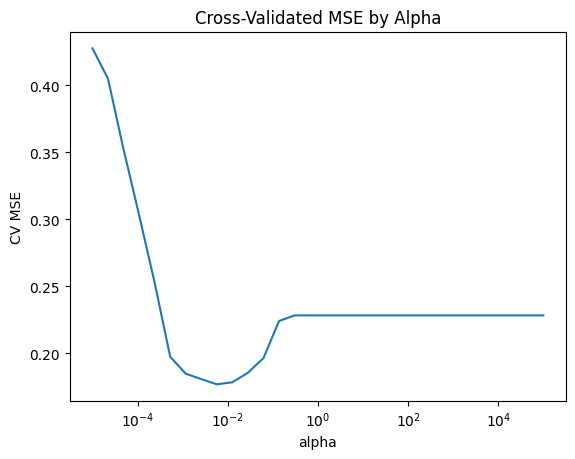

In [32]:
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("Cross-Validated MSE by Alpha")
plt.show()

## 5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.602e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.167e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

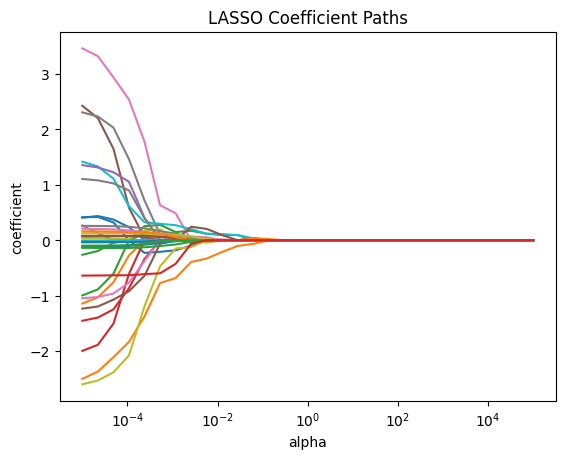

In [33]:
coef_path = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=20000)
    model.fit(X, y)
    coef_path.append(model.coef_)

coef_path = np.array(coef_path)

for i in range(coef_path.shape[1]):
    plt.plot(alphas, coef_path[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficient")
plt.title("LASSO Coefficient Paths")
plt.show()

## 6)

In [34]:
lasso_coefs = pd.Series(lasso.coef_, index=features)

print("Selected features:")
print(lasso_coefs[lasso_coefs != 0])

print("Proportion set to zero:")
print((lasso_coefs == 0).mean())

comparison = pd.DataFrame({
    "Linear": lr.coef_,
    "LASSO": lasso.coef_
}, index=features)

print(comparison)

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Proportion set to zero:
0.6470588235294118
                                                Linear     LASSO
age                                           1.619432 -0.000000
ejection_fraction                            -2.062277 -0.329656
serum_creatinine                             -0.757092  0.116875
age^2                                        -3.717758  0.000000
age ejecti

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

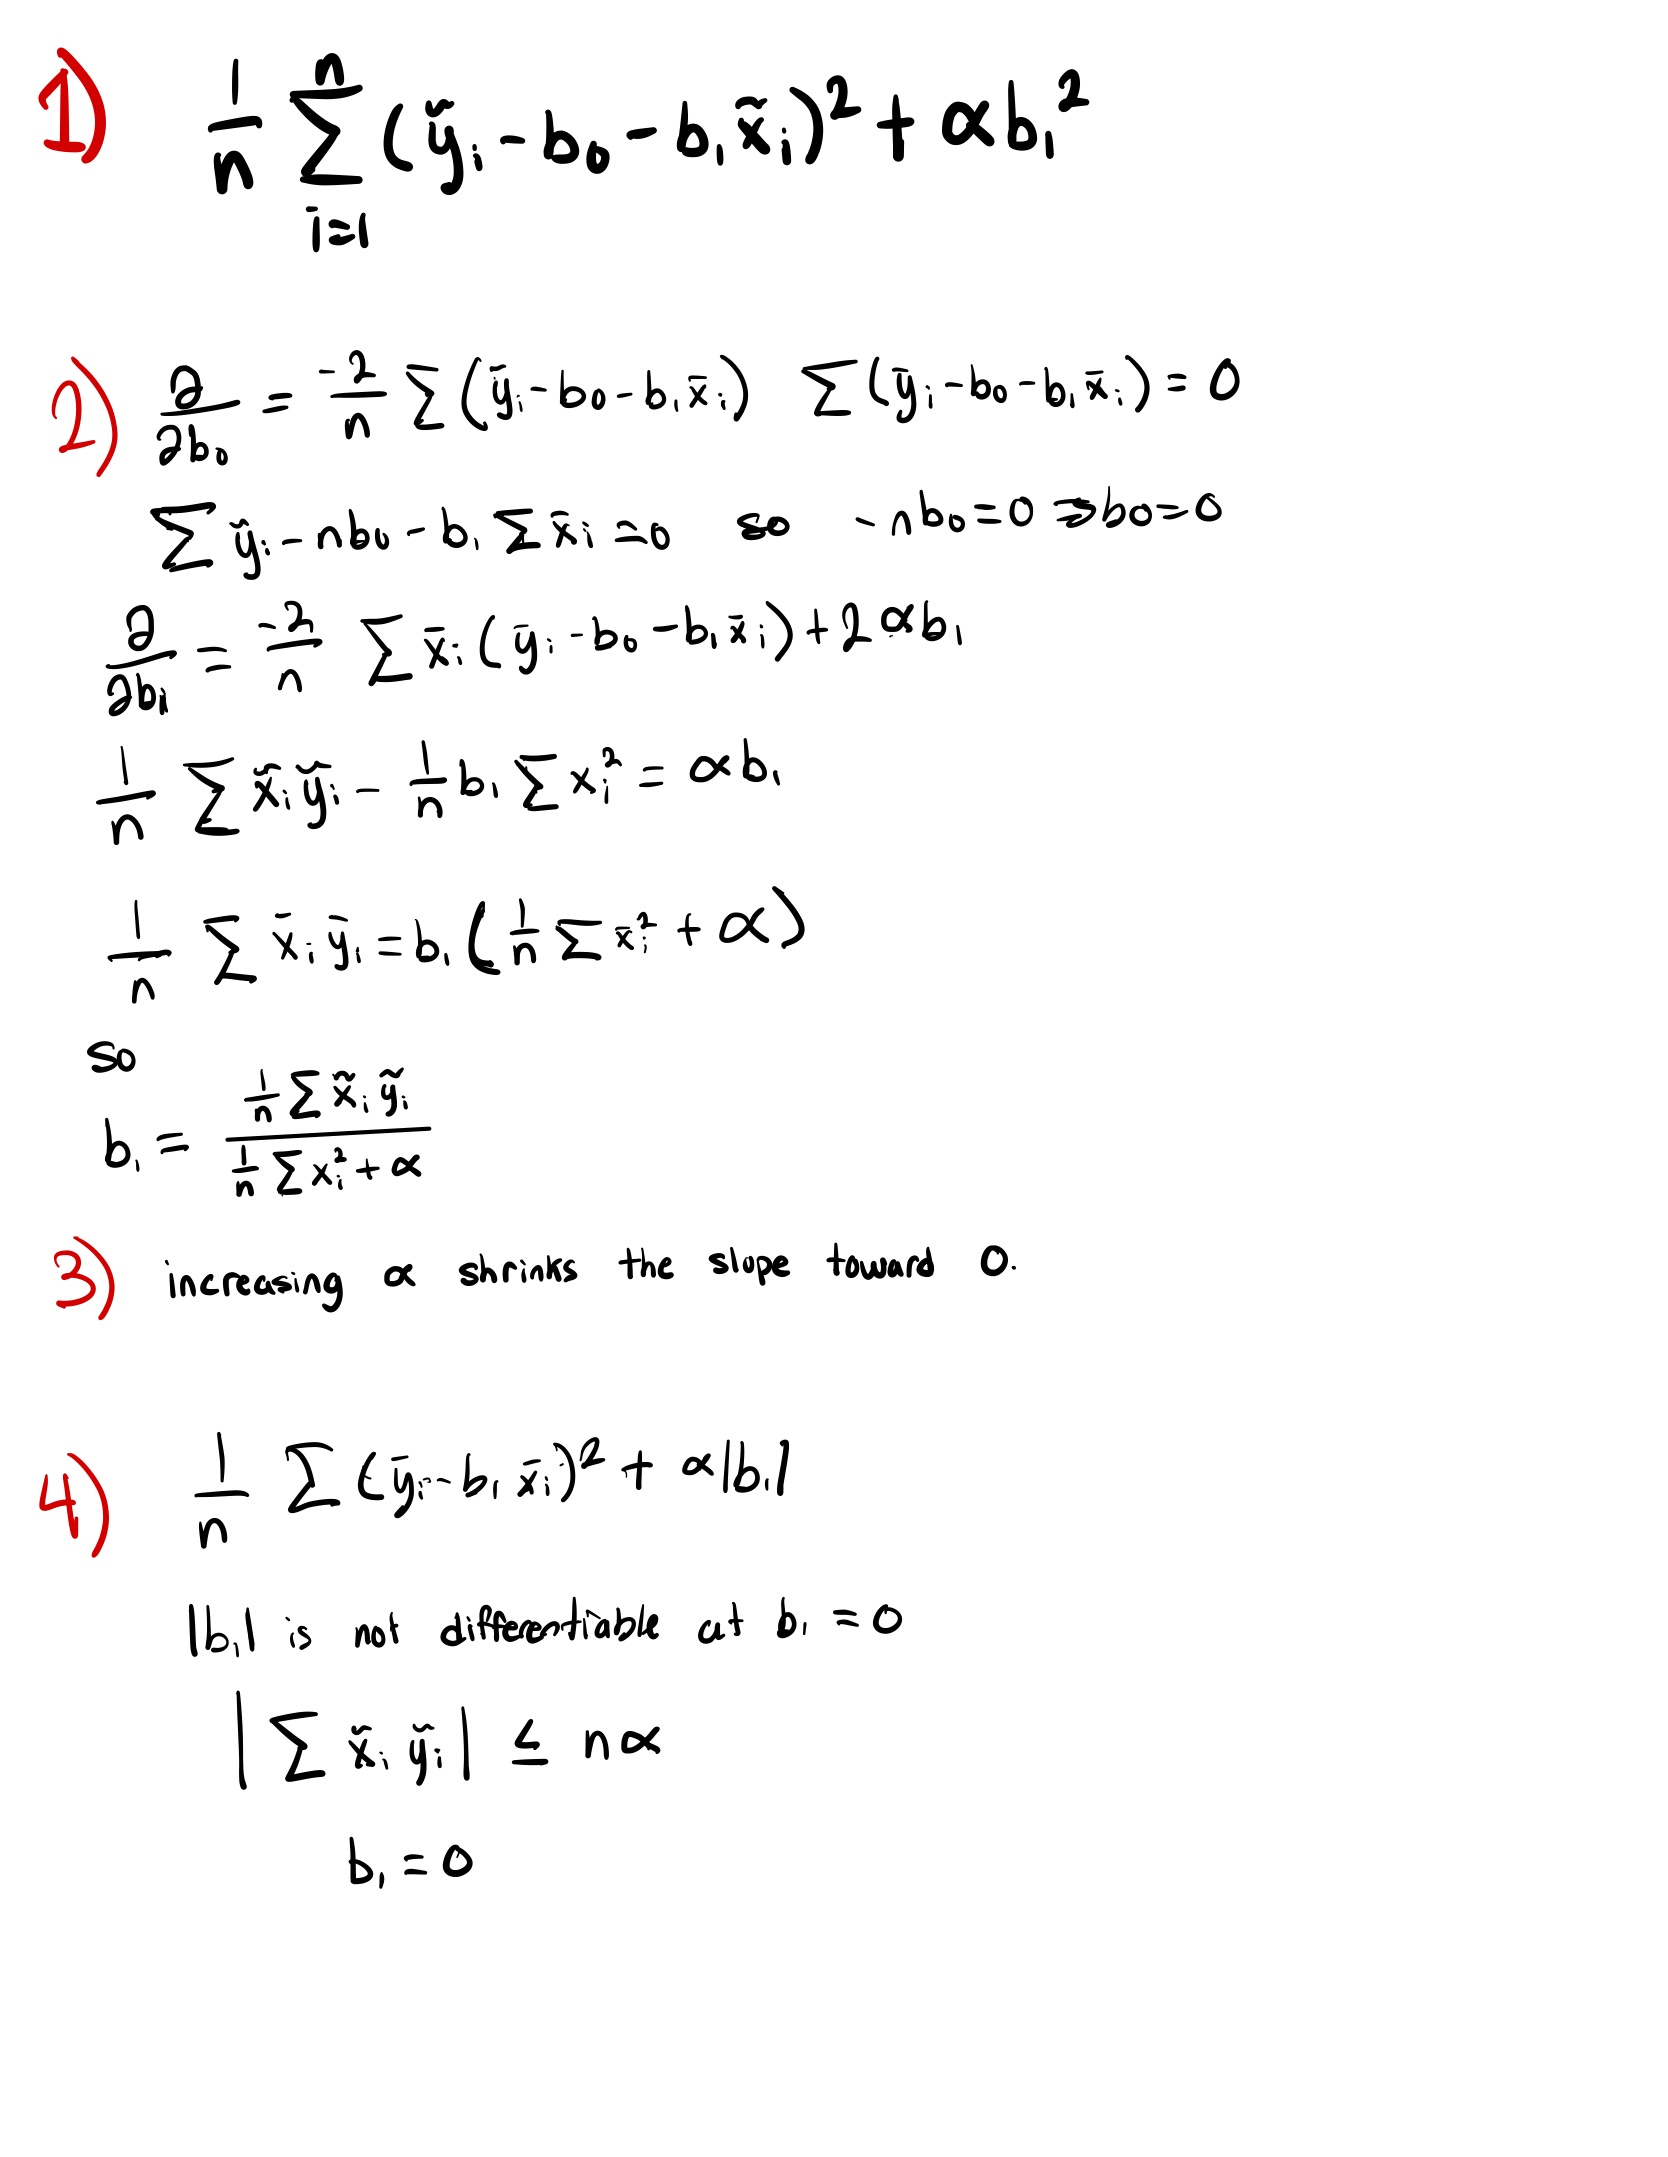

In [37]:
from IPython.display import Image, display

display(Image("data/A4.jpg"))